## Data Preprocessing and Preparation

In [ ]:
import cv2
import numpy as np
import os
import random
from tqdm import tqdm
from PIL import Image, ImageEnhance
from albumentations import (HorizontalFlip, ShiftScaleRotate, GaussNoise, 
                            RandomBrightnessContrast, RandomGamma, 
                            ElasticTransform, GaussianBlur)
import matplotlib.pyplot as plt
import json
from collections import defaultdict

def enhance_image(image):
    pil_image = Image.fromarray(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    enhancer = ImageEnhance.Sharpness(pil_image)
    enhanced_image = enhancer.enhance(2.0)
    return cv2.cvtColor(np.array(enhanced_image), cv2.COLOR_RGB2BGR)

def resize_image(image):
    return cv2.resize(image, (224, 224))

def preprocessing(image):
    image = resize_image(image)
    image = enhance_image(image)
    return image

# Add salt-and-pepper noise
def add_salt_and_pepper_noise(image, amount=0.01, salt_vs_pepper=0.5):
    row, col, ch = image.shape
    num_salt = np.ceil(amount * image.size * salt_vs_pepper)
    num_pepper = np.ceil(amount * image.size * (1.0 - salt_vs_pepper))

    coords = [np.random.randint(0, i - 1, int(num_salt)) for i in image.shape]
    image[coords[0], coords[1], :] = 1

    coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in image.shape]
    image[coords[0], coords[1], :] = 0
    return image

# Get random augmentations for an image
def get_random_augmentations(existing_combinations, img_name):
    while True:
        num_transformations = random.randint(1, len(augmentation_methods))
        selected_names = random.sample(list(augmentation_methods.keys()), num_transformations)
        combination_key = tuple(sorted(selected_names))

        if combination_key not in existing_combinations.get(img_name, set()):
            return selected_names

# Apply augmentations
def apply_augmentations(img, augmentations, augmented_images_count):
    transformation_labels = []
    applied_types = set()

    for aug in augmentations:
        if aug in augmentation_methods:
            transform, transform_type = augmentation_methods[aug]

            if transform_type not in applied_types:
                if aug == "salt_and_pepper":
                    img = add_salt_and_pepper_noise(img)
                else:
                    img = transform(image=img)["image"]

                transformation_labels.append(aug)
                applied_types.add(transform_type)

    return img, transformation_labels, augmented_images_count + 1

# Apply augmentations and save the augmented image
def augment_image(img, img_name, augmentations, output_dir, existing_combinations, augmented_images_count):
    transformed, transformation_labels, augmented_images_count = apply_augmentations(img, augmentations, augmented_images_count)

    base_name = os.path.splitext(img_name)[0]
    unique_name = f"{base_name}_{augmented_images_count}.jpg"
    output_path = os.path.join(output_dir, unique_name)
    cv2.imwrite(output_path, transformed)

    combination_key = tuple(sorted(transformation_labels))
    if img_name not in existing_combinations:
        existing_combinations[img_name] = set()
    existing_combinations[img_name].add(combination_key)

    transformation_metadata = {aug: augmentation_methods[aug][1] for aug in transformation_labels}
    
    return augmented_images_count, transformation_metadata, unique_name

# Augment dataset until target size is reached
def augment_dataset(augmented_class_path, target_image_count):
    augmented_images_count = len(os.listdir(augmented_class_path))
    print(f'Initial augmented images count: {augmented_images_count}')

    existing_combinations = {}
    augmentation_metadata = {}

    while augmented_images_count < target_image_count:
        for img_name in os.listdir(augmented_class_path):
            img = cv2.imread(os.path.join(augmented_class_path, img_name))

            augmentations = get_random_augmentations(existing_combinations, img_name)

            augmented_images_count, transformation_metadata, saved_image_name = augment_image(
                img, img_name, augmentations, augmented_class_path, existing_combinations, augmented_images_count
            )

            augmentation_metadata[saved_image_name] = transformation_metadata
            print(f'Augmented image saved: {saved_image_name}, Count: {augmented_images_count}')
            
            if augmented_images_count >= target_image_count:
                break

    save_metadata(augmentation_metadata, './Datasets/augmentation_metadata.json')
    print(f'Final augmented images count: {augmented_images_count}')

def create_datasets():
    raw_data_dir = './Datasets/Dataset_O'
    small_data_dir = './Datasets/Dataset_S'
    large_data_dir = './Datasets/Dataset_L'
    target_large_dataset_size = 40000

    os.makedirs(small_data_dir, exist_ok=True)
    os.makedirs(large_data_dir, exist_ok=True)

    classes = os.listdir(raw_data_dir)
    excluded_images = set()

    for class_name in classes:
        class_path = os.path.join(raw_data_dir, class_name)
        small_class_path = os.path.join(small_data_dir, class_name)
        
        os.makedirs(small_class_path, exist_ok=True)
        excluded_images.update(save_small_dataset(class_path, small_class_path))

    copy_raw_to_large_dataset(raw_data_dir, large_data_dir, excluded_images)
    augment_dataset(large_data_dir, target_large_dataset_size)

def save_small_dataset(class_path, small_class_path, num_small_images=500):
    images = [img for img in os.listdir(class_path) if img.endswith(('.png', '.jpg', '.jpeg'))]
    selected_images = images[:num_small_images]
    excluded_images = set(selected_images)

    for img_name in tqdm(selected_images, desc=f'Saving small dataset for {class_path}'):
        img = cv2.imread(os.path.join(class_path, img_name))
        img_processed = preprocessing(img)
        cv2.imwrite(os.path.join(small_class_path, img_name), img_processed)

    return excluded_images

def copy_raw_to_large_dataset(raw_data_dir, large_data_dir, excluded_images):
    for dirpath, _, filenames in tqdm(os.walk(raw_data_dir), desc='Copying images to large dataset'):
        for img_name in filenames:
            if img_name.endswith(('.png', '.jpg', '.jpeg')) and img_name not in excluded_images:
                src_path = os.path.join(dirpath, img_name)
                dst_path = os.path.join(large_data_dir, img_name)

                base_name, ext = os.path.splitext(img_name)
                counter = 1
                while os.path.exists(dst_path):
                    dst_path = os.path.join(large_data_dir, f"{base_name}_{counter}{ext}")
                    counter += 1

                cv2.imwrite(dst_path, cv2.imread(src_path))

def save_metadata(metadata, output_file):
    with open(output_file, 'w') as f:
        json.dump(metadata, f, indent=4)

# Augmentation methods with their types
augmentation_methods = {
    "horizontal_flip": (HorizontalFlip(p=0.5), "geometric"),
    "shift_scale_rotate": (ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=0, p=0.5), "geometric"),
    "gauss_noise": (GaussNoise(var_limit=(0, 10), p=0.4), "noise"),
    "brightness_contrast": (RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.6), "color"),
    "random_gamma": (RandomGamma(gamma_limit=(85, 115), p=0.4), "color"),
    "elastic_transform": (ElasticTransform(alpha=1, sigma=50, p=0.5), "other"),
    "gaussian_blur": (GaussianBlur(blur_limit=(1, 3), p=0.5), "other"),
    "salt_and_pepper": ("salt_and_pepper", "noise")
}

create_datasets()


## Preprocessed Data Plots

In [ ]:
def load_metadata(metadata_file):
    with open(metadata_file, "r") as f:
        return json.load(f)


def plot_transformation_counts(metadata_file):
    metadata = load_metadata(metadata_file)

    transformation_counts = {}

    for image_data in metadata.values():
        for transformation in image_data:
            if transformation in transformation_counts:
                transformation_counts[transformation] += 1
            else:
                transformation_counts[transformation] = 1

    plt.figure(figsize=(10, 6))
    bars = plt.bar(
        transformation_counts.keys(), transformation_counts.values(), color="skyblue"
    )
    plt.xlabel("Transformation")
    plt.ylabel("Count")
    plt.title("Count of Each Transformation")
    plt.xticks(rotation=45)
    plt.tight_layout()

    for bar in bars:
        yval = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            yval + 0.05,
            int(yval),
            ha="center",
            va="bottom",
        )

    plt.show()


metadata_file = "./Datasets/augmentation_metadata.json"
plot_transformation_counts(metadata_file)


def plot_transformation_type_counts(metadata_file):
    metadata = load_metadata(metadata_file)

    type_counts = {}

    for image_data in metadata.values():
        for transformation, transformation_type in image_data.items():
            if transformation_type in type_counts:
                type_counts[transformation_type] += 1
            else:
                type_counts[transformation_type] = 1

    plt.figure(figsize=(10, 6))
    bars = plt.bar(type_counts.keys(), type_counts.values(), color="orange")
    plt.xlabel("Transformation Type")
    plt.ylabel("Count")
    plt.title("Count of Each Type of Transformation")
    plt.xticks(rotation=45)
    plt.tight_layout()

    for bar in bars:
        yval = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            yval + 0.05,
            int(yval),
            ha="center",
            va="bottom",
        )

    plt.show()


plot_transformation_type_counts(metadata_file)

## MAE Model PRETRAIN (n% mask ratio)

In [ ]:
import subprocess
import os

# Set the environment variable
os.environ["SAVE_DIR"] = r"C:\Coding\Python\Projects\medical_mae\models\pretrained_chestCT"

# Define the command and its arguments
command = [
    "python", "main_pretrain_multi_datasets_xray_cnn.py",
    "--output_dir", os.environ["SAVE_DIR"],
    "--log_dir", os.environ["SAVE_DIR"],
    "--batch_size", "16",
    "--model", "densenet121",
    "--device", "cuda",
    "--mask_ratio", "0.95",
    "--epochs", "100",
    "--warmup_epochs", "5",
    "--blr", "1.5e-4",
    "--weight_decay", "0.05",
    "--num_workers", "8",
    "--input_size", "224",
    "--datasets_names", "chestct_custom"
]

# Run the command and print output in real-time
process = subprocess.Popen(command, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)

# Print each line of output as it appears
for line in process.stdout:
    print(line, end="")

# Wait for the process to complete and check for any errors
process.wait()
for line in process.stderr:
    print(line, end="")


Not using distributed mode
[22:09:13.948364] job dir: C:\Coding\Python\Projects\medical_mae
[22:09:13.948364] Namespace(accum_iter=1,
batch_size=16,
blr=0.00015,
data_path='/datasets01/imagenet_full_size/061417/',
datasets_names=['chestct_custom'],
device='cuda',
dist_on_itp=False,
dist_url='env://',
distributed=False,
epochs=100,
fixed_lr=False,
input_size=224,
local_rank=-1,
log_dir='C:\\Coding\\Python\\Projects\\medical_mae\\models\\pretrained_chestCT',
lr=None,
mask_ratio=0.95,
mask_strategy='random',
min_lr=0.0,
model='densenet121',
norm_pix_loss=False,
num_workers=8,
output_dir='C:\\Coding\\Python\\Projects\\medical_mae\\models\\pretrained_chestCT',
pin_mem=True,
random_resize_range=None,
repeated_aug=False,
resume='',
seed=0,
start_epoch=0,
train_list=None,
warmup_epochs=5,
weight_decay=0.05,
world_size=1)
[22:09:13.989909] ['chestct_custom']
[22:09:13.989909] Using Directly-Resize Mode. (no RandomResizedCrop)
[22:09:14.109641] Found 40000 images in Datasets/Dataset_L
[22:09:14.

## Best mask percentage decision

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import models_mae_cnn
import os
from tqdm import tqdm

# Define checkpoints and dataset directory
checkpoints = [
    './models/0.75/checkpoint-99-mae-pretrain-75.pth',
    './models/0.80/checkpoint-99-mae-pretrain-80.pth',
    './models/0.85/checkpoint-99-mae-pretrain-85.pth',
    './models/0.90/checkpoint-99-mae-pretrain-90.pth',
    './models/0.95/checkpoint-99-mae-pretrain-95.pth'
]
data_dir = './Datasets/Dataset_L'
img_list_val = [os.path.join(data_dir, file_name) for file_name in os.listdir(data_dir)]

chestxray_mean = np.array([0.485, 0.456, 0.406])
chestxray_std = np.array([0.229, 0.224, 0.225])

# Image loading and display functions
def load_img_gray(path, size=224, mean=chestxray_mean, std=chestxray_std):
    img = Image.open(path).convert('RGB')
    img = img.resize((size, size))
    img = np.array(img) / 255.
    img = (img - mean) / std
    return img

def show_image(image, title='', mean=chestxray_mean, std=chestxray_std):
    plt.imshow(torch.clip((image * std + mean) * 255, 0, 255).int()[:, :, 0], cmap='gray')
    plt.title(title, fontsize=16)
    plt.axis('off')

# Model preparation function
def prepare_model_cnn(chkpt_dir, model_arch='Unet', encoder_model='densenet121'):
    model = models_mae_cnn.MaskedAutoencoderCNN(img_size=224, patch_size=16, model_arch=model_arch, encoder_name=encoder_model)
    checkpoint = torch.load(chkpt_dir, map_location='cuda')
    model.load_state_dict(checkpoint['model'], strict=False)
    return model

# Reconstruction function
def reconstruct_image(model, img, mask_ratio=0.75):
    x = torch.tensor(img).unsqueeze(0).permute(0, 3, 1, 2)
    loss, y, mask = model(x.float(), mask_ratio=mask_ratio)
    y = y.permute(0, 2, 3, 1).squeeze().detach().cpu().numpy()
    return loss.item(), y

# Evaluate each checkpoint across the dataset
best_checkpoint = None
lowest_avg_loss = float('inf')
checkpoint_losses = {}

for chkpt_path in checkpoints:
    print(f"Evaluating checkpoint: {chkpt_path}")
    model = prepare_model_cnn(chkpt_path)
    losses = []

    for img_path in tqdm(img_list_val, desc="Processing Images"):
        img_val = load_img_gray(img_path)
        loss, _ = reconstruct_image(model, img_val, mask_ratio=0.75)
        losses.append(loss)
    
    avg_loss = np.mean(losses)
    checkpoint_losses[chkpt_path] = avg_loss

    # Check if this is the lowest average loss
    if avg_loss < lowest_avg_loss:
        lowest_avg_loss = avg_loss
        best_checkpoint = chkpt_path

    print(f"Checkpoint {chkpt_path} - Average Reconstruction Loss: {avg_loss:.4f}")

print(f"\nBest Checkpoint: {best_checkpoint} with Lowest Average Loss: {lowest_avg_loss:.4f}")

## Classification using Few Shot Learning 

### Relation Networks

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from torch.optim import Adam
import numpy as np
from torchvision import datasets, transforms
from tqdm import tqdm

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Function to load pretrained encoder (DenseNet-121)
def load_pretrained_encoder(checkpoint_path):
    densenet = models.densenet121(pretrained=False)
    checkpoint = torch.load(checkpoint_path, map_location=device)
    densenet.load_state_dict(checkpoint['model'], strict=False)  # Load encoder weights
    encoder = densenet.features
    return encoder

# Define the Relation Network class
class RelationNetwork(nn.Module):
    def __init__(self, encoder, embedding_size=50176, hidden_size=1024, output_size=3):
        super(RelationNetwork, self).__init__()
        self.encoder = encoder
        self.fc1 = nn.Linear(embedding_size * 2, hidden_size)  # Compare the embeddings of pairs
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=-1)
    
    def forward(self, support_set, query_set):
        # Get embeddings from the encoder
        support_embed = self.encoder(support_set)
        query_embed = self.encoder(query_set)
       
        # Flatten the output from the encoder to a vector
        support_embed = torch.flatten(support_embed, 1)  # Flatten from the second dimension (channel dimension)
        query_embed = torch.flatten(query_embed, 1)
        
        # Compute pairwise relations
        relation_input = torch.cat([support_embed, query_embed], dim=-1)
        x = self.fc1(relation_input)
        x = self.relu(x)
        x = self.fc2(x)
        return self.softmax(x)

# Early stopping class
class EarlyStopping:
    def __init__(self, patience=5, delta=0):
        self.patience = patience
        self.delta = delta
        self.best_score = None
        self.early_stop = False
        self.counter = 0
    
    def __call__(self, val_loss, model):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0
    
    def save_checkpoint(self, val_loss, model):
        torch.save(model.state_dict(), './models/relation_networks/relation.pth')

# Load dataset (adjust according to your dataset)
train_transforms = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor()])
dataset = datasets.ImageFolder('./Datasets/Dataset_S', transform=train_transforms)

# Split dataset into training and validation sets
train_dataset, val_dataset = train_test_split(dataset, test_size=0.2, stratify=dataset.targets)

# Loaders for training and validation
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

# Model, optimizer, and loss function
pretrain_encoder_path = f"./models/0.90/checkpoint-99-mae-pretrain-90.pth"
encoder = load_pretrained_encoder(pretrain_encoder_path).to(device)
relation_network = RelationNetwork(encoder, embedding_size=50176).to(device)
optimizer = Adam(relation_network.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

# Early stopping
early_stopping = EarlyStopping(patience=5, delta=0.01)

# Training loop with validation
epochs = 50
for epoch in range(epochs):
    relation_network.train()
    running_loss = 0.0
    # Wrap the train_loader with tqdm for progress monitoring
    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} - Training", leave=False):
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        # Forward pass through the relation network
        outputs = relation_network(inputs, inputs)  # Example: using inputs for both support and query set
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()

    # Validation phase
    relation_network.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    # Wrap the val_loader with tqdm for progress monitoring
    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} - Validation", leave=False):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = relation_network(inputs, inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    # Calculate validation accuracy
    val_accuracy = 100 * correct / total
    print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {running_loss/len(train_loader):.4f}, Validation Loss: {val_loss/len(val_loader):.4f}, Validation Accuracy: {val_accuracy:.2f}%")

    # Check early stopping criteria
    early_stopping(val_loss/len(val_loader), relation_network)
    if early_stopping.early_stop:
        print("Early stopping")
        break

# Load the best model (after early stopping)
relation_network.load_state_dict(torch.load('./models/relation_networks/relation.pth'))

# Evaluation metrics on the validation set
relation_network.eval()
all_labels = []
all_preds = []

# Evaluation loop
for inputs, labels in tqdm(val_loader, desc="Evaluation", leave=False):
    inputs, labels = inputs.to(device), labels.to(device)
    
    with torch.no_grad():
        outputs = relation_network(inputs, inputs)
    
    _, predicted = torch.max(outputs, 1)
    all_labels.append(labels.cpu().numpy())
    all_preds.append(predicted.cpu().numpy())

# Flatten lists of labels and predictions
all_labels = np.concatenate(all_labels)
all_preds = np.concatenate(all_preds)

# Accuracy, Precision, Recall, F1 Score
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='weighted')
recall = recall_score(all_labels, all_preds, average='weighted')
f1 = f1_score(all_labels, all_preds, average='weighted')

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

# Print Results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Confusion Matrix:\n{cm}")


c:\Coding\Python\Projects\medical_mae\.conda\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Coding\Python\Projects\medical_mae\.conda\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Epoch [1/50], Train Loss: 0.7889, Validation Loss: 0.6919, Validation Accuracy: 86.00%


Epoch [2/50], Train Loss: 0.7242, Validation Loss: 0.6930, Validation Accuracy: 85.67%


Epoch [3/50], Train Loss: 0.6888, Validation Loss: 0.6531, Validation Accuracy: 89.67%


Epoch [4/50], Train Loss: 0.6457, Validation Loss: 0.6664, Validation Accuracy: 88.33%


...

Epoch [10/50], Train Loss: 0.6117, Validation Loss: 0.6104, Validation Accuracy: 94.33%


Epoch [11/50], Train Loss: 0.6493, Validation Loss: 0.7184, Validation Accuracy: 83.33%


Epoch [12/50], Train Loss: 0.6775, Validation Loss: 0.6205, Validation Accuracy: 93.00%


Epoch [13/50], Train Loss: 0.6366, Validation Loss: 0.6666, Validation Accuracy: 88.33%
Early stopping


Accuracy: 0.9433
Precision: 0.9473
Recall: 0.9433
F1 Score: 0.9427
Confusion Matrix:
[[ 86   7   7]
 [  0  97   3]
 [  0   0 100]]


#### Relation Networks Testing

In [5]:
# Load the whole dataset (without splitting into training and validation)
full_dataset = datasets.ImageFolder('./Datasets/Dataset_S', transform=train_transforms)
full_loader = DataLoader(full_dataset, batch_size=16, shuffle=True)  # Shuffle added for variety

# Load the best model (after training or early stopping)
relation_network.load_state_dict(torch.load('relation.pth'))

# Evaluation metrics on the whole dataset
relation_network.eval()
all_labels = []
all_preds = []

# Evaluation loop for the whole dataset
for inputs, labels in tqdm(full_loader, desc="Testing on Full Dataset", leave=False):
    inputs, labels = inputs.to(device), labels.to(device)

    with torch.no_grad():
        outputs = relation_network(inputs, inputs)  # Evaluate on both support and query sets

    _, predicted = torch.max(outputs, 1)
    all_labels.append(labels.cpu().numpy())
    all_preds.append(predicted.cpu().numpy())

# Flatten lists of labels and predictions
all_labels = np.concatenate(all_labels)
all_preds = np.concatenate(all_preds)

# Accuracy, Precision, Recall, F1 Score
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='weighted')
recall = recall_score(all_labels, all_preds, average='weighted')
f1 = f1_score(all_labels, all_preds, average='weighted')

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

# Print Results
print(f"Accuracy on Full Dataset: {accuracy:.4f}")
print(f"Precision on Full Dataset: {precision:.4f}")
print(f"Recall on Full Dataset: {recall:.4f}")
print(f"F1 Score on Full Dataset: {f1:.4f}")
print(f"Confusion Matrix on Full Dataset:\n{cm}")


Accuracy on Full Dataset: 0.9480
Precision on Full Dataset: 0.9528
Recall on Full Dataset: 0.9480
F1 Score on Full Dataset: 0.9481
Confusion Matrix on Full Dataset:
[[444  13  43]
 [  0 478  22]
 [  0   0 500]]


### Prototypical Networks

In [50]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from sklearn.metrics import accuracy_score, precision_score, f1_score, confusion_matrix
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define transformations with normalization for ImageNet
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  # ImageNet mean and std
])

# Load dataset and split into train/test sets
dataset_path = './Datasets/Dataset_S'
full_dataset = datasets.ImageFolder(root=dataset_path, transform=transform)
num_classes = len(full_dataset.classes)

train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Save the class-to-index mapping
class_to_idx_path = './models/prototypical_networks/class_to_idx.pth'
os.makedirs(os.path.dirname(class_to_idx_path), exist_ok=True)
torch.save(full_dataset.class_to_idx, class_to_idx_path)

# Load pretrained encoder weights from checkpoint into a torchvision DenseNet model
def load_pretrained_encoder(checkpoint_path):
    densenet = models.densenet121(pretrained=False)
    checkpoint = torch.load(checkpoint_path, map_location='cpu')
    densenet.load_state_dict(checkpoint['model'], strict=False)  # Load encoder weights
    encoder = densenet.features
    encoder.eval()  # Set encoder to eval mode
    return encoder

encoder = load_pretrained_encoder("./models/0.90/checkpoint-99-mae-pretrain-90.pth")
encoder.to(device)

# Function to extract features using the encoder
def extract_features(encoder, images):
    with torch.no_grad():
        features = encoder(images)  # Get DenseNet features
        features = torch.flatten(features, start_dim=1)  # Flatten for linear classification
        # print feature shape
    return features

# Compute prototypes (average feature vector) per class
def compute_prototypes(features, labels, num_classes):
    prototypes = torch.zeros((num_classes, features.size(1)), device=device)
    for i in range(num_classes):
        class_features = features[labels == i]
        if class_features.size(0) > 0:
            prototypes[i] = class_features.mean(dim=0)
    return prototypes

def classify_query(query_features, prototypes):
    query_features = F.normalize(query_features, p=2, dim=1)
    prototypes = F.normalize(prototypes, p=2, dim=1)
    distances = torch.cdist(query_features, prototypes, p=2)
    return distances.argmin(dim=1)


# Training loop with early stopping
patience = 5
best_val_loss = float('inf')
epochs_no_improve = 0
num_epochs = 50

for epoch in range(num_epochs):
    # Training phase
    encoder.train()
    train_features, train_labels = [], []

    for images, labels in tqdm(train_loader, desc=f"Training Epoch {epoch+1}/{num_epochs}", unit='batch'):
        images, labels = images.to(device), labels.to(device)
        features = extract_features(encoder, images)
        train_features.append(features)
        train_labels.append(labels)

    train_features = torch.cat(train_features)
    train_labels = torch.cat(train_labels)

    # Compute prototypes for few-shot classification
    encoder.eval()
    prototypes = compute_prototypes(train_features, train_labels, num_classes)

    # Save prototypes after training
    prototypes_path = './models/prototypical_networks/class_prototypes.pth'
    torch.save(prototypes, prototypes_path)

    # Validation phase
    val_losses = []
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc=f"Validating Epoch {epoch+1}/{num_epochs}", unit='batch'):
            images, labels = images.to(device), labels.to(device)
            query_features = extract_features(encoder, images)

            preds = classify_query(query_features, prototypes)
            scores = torch.cdist(query_features, prototypes)
            logits = -scores  # Convert distances to logits for cross-entropy

            # Calculate loss
            loss = F.cross_entropy(logits, labels)
            val_losses.append(loss.item())

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Calculate validation metrics
    val_loss = np.mean(val_losses)
    val_accuracy = accuracy_score(all_labels, all_preds)
    print(f"Epoch {epoch+1}/{num_epochs}, Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}")

    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        encoder_path = './models/prototypical_networks/encoder.pth'
        torch.save(encoder.state_dict(), encoder_path)
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print("Early stopping triggered")
            break

# Save final validation metrics
metrics = {
    "best_val_loss": best_val_loss,
    "final_accuracy": val_accuracy,
}
metrics_path = './models/prototypical_networks/validation_metrics.pth'
torch.save(metrics, metrics_path)

print("Training complete. All required components saved.")


c:\Coding\Python\Projects\medical_mae\.conda\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Coding\Python\Projects\medical_mae\.conda\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
Validating Epoch 1/50: 100%|██████████| 10/10 [00:01<00:00,  7.40batch/s]


Epoch 1/50, Val Loss: 2.8191, Val Accuracy: 0.8633


Validating Epoch 2/50: 100%|██████████| 10/10 [00:01<00:00,  7.53batch/s]


Epoch 2/50, Val Loss: 2.7203, Val Accuracy: 0.8667


Validating Epoch 3/50: 100%|██████████| 10/10 [00:01<00:00,  7.59batch/s]


...

Epoch 10/50, Val Loss: 2.6759, Val Accuracy: 0.8600


Validating Epoch 11/50: 100%|██████████| 10/10 [00:01<00:00,  7.25batch/s]


Epoch 11/50, Val Loss: 2.6748, Val Accuracy: 0.8633


Validating Epoch 12/50: 100%|██████████| 10/10 [00:01<00:00,  7.29batch/s]

Epoch 12/50, Val Loss: 2.6191, Val Accuracy: 0.8633
Early stopping triggered
Training complete. All required components saved.


#### Prototypical Networks testing

In [1]:
import os
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, f1_score, confusion_matrix
from tqdm import tqdm

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define transformations with normalization for ImageNet
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),  # ImageNet mean and std
])

# Load dataset
dataset_path = './Datasets/Dataset_S'
full_dataset = datasets.ImageFolder(root=dataset_path, transform=transform)
num_classes = len(full_dataset.classes)

test_loader = DataLoader(full_dataset, batch_size=32, shuffle=False)

# Load class-to-index mapping
class_to_idx_path = './models/prototypical_networks/class_to_idx.pth'
class_to_idx = torch.load(class_to_idx_path)
print(class_to_idx)


# Load prototypes
prototypes_path = './models/prototypical_networks/class_prototypes.pth'
prototypes = torch.load(prototypes_path)
prototypes = prototypes.to(device)

# Load pretrained encoder weights into DenseNet model
def load_pretrained_encoder(checkpoint_path):
    densenet = models.densenet121(pretrained=False)
    checkpoint = torch.load(checkpoint_path, map_location='cpu')
    densenet.load_state_dict(checkpoint, strict=False)
    encoder = densenet.features
    encoder.eval()
    return encoder

encoder = load_pretrained_encoder("./models/prototypical_networks/encoder.pth")
encoder.to(device)

# Function to extract features using the encoder
def extract_features(encoder, images):
    with torch.no_grad():
        features = encoder(images)
        features = torch.flatten(features, start_dim=1)
    return features

def l2_normalize(x):
    norm = x.norm(p=2, dim=1, keepdim=True)
    return x / norm

# Classify query samples by distance to prototypes
def classify_query(query_features, prototypes):
    query_features = l2_normalize(query_features)
    prototypes = l2_normalize(prototypes)
    distances = torch.cdist(query_features, prototypes, p=2)
    return distances.argmin(dim=1)

# Evaluation on test set
encoder.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing", unit='batch'):
        images, labels = images.to(device), labels.to(device)
        query_features = extract_features(encoder, images)

        preds = classify_query(query_features, prototypes)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calculate evaluation metrics
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='macro')
f1 = f1_score(all_labels, all_preds, average='macro')
cm = confusion_matrix(all_labels, all_preds)

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test F1 Score: {f1:.4f}")
print("Confusion Matrix:")
print(cm)


In [5]:
from sklearn.metrics import recall_score

# Load the new dataset and apply the same transformation
test_dataset_path = './Datasets/Dataset_O'
test_dataset = datasets.ImageFolder(root=test_dataset_path, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Function to test the model on the new dataset
def test_model(encoder, test_loader, prototypes):
    encoder.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Testing on New Dataset", unit='batch'):
            images, labels = images.to(device), labels.to(device)
            query_features = extract_features(encoder, images)

            preds = classify_query(query_features, prototypes)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Calculate final metrics
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted')
    f1 = f1_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')
    conf_matrix = confusion_matrix(all_labels, all_preds)

    print(f"Test Accuracy: {accuracy:.4f}")
    print(f"Test Precision: {precision:.4f}")
    print(f"Test F1 Score: {f1:.4f}")
    print(f"Test Recall: {recall:.4f}")
    print(f"Test Confusion Matrix:\n{conf_matrix}")

# Load the best encoder model (from the trained model)
encoder.load_state_dict(torch.load('./models/prototypical_networks/encoder.pth'))
print("Best encoder model loaded.")

# Test the model on the new dataset
test_model(encoder, test_loader, prototypes)


Best encoder model loaded.


Testing on New Dataset: 100%|██████████| 236/236 [00:57<00:00,  4.12batch/s]

Test Accuracy: 0.4628
Test Precision: 0.5468
Test F1 Score: 0.4270
Test Recall: 0.4628
Test Confusion Matrix:
[[ 492  367 1176]
 [   0 1971  148]
 [  84 2278 1028]]


### Simple Densenet121 model

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np
import os
from tqdm import tqdm

# Hyperparameters
BATCH_SIZE = 32
LEARNING_RATE = 1e-4
EPOCHS = 50
PATIENCE = 5  # Early stopping patience

# Directories
train_dir = './Datasets/Dataset_S'

# Transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Dataset and Dataloader
dataset = datasets.ImageFolder(train_dir, transform=transform)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Define model
model = models.densenet121()
model.classifier = nn.Linear(model.classifier.in_features, len(dataset.classes))  # Adjust for dataset classes
model = model.to('cuda' if torch.cuda.is_available() else 'cpu')

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Early stopping
best_val_loss = float('inf')
patience_counter = 0

# Training loop
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    # Training
    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", ncols=100):
        inputs, labels = inputs.to('cuda' if torch.cuda.is_available() else 'cpu'), labels.to('cuda' if torch.cuda.is_available() else 'cpu')

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_accuracy = correct / total
    print(f"Train Loss: {running_loss/len(train_loader)}, Train Accuracy: {train_accuracy * 100}%")

    # Validation
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to('cuda' if torch.cuda.is_available() else 'cpu'), labels.to('cuda' if torch.cuda.is_available() else 'cpu')
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())

    val_accuracy = val_correct / val_total
    val_precision = precision_score(all_labels, all_preds, average='weighted')
    val_recall = recall_score(all_labels, all_preds, average='weighted')
    val_f1 = f1_score(all_labels, all_preds, average='weighted')
    val_cm = confusion_matrix(all_labels, all_preds)

    print(f"Val Loss: {val_loss/len(val_loader)}, Val Accuracy: {val_accuracy * 100}%")
    print(f"Val Precision: {val_precision}, Val Recall: {val_recall}, Val F1: {val_f1}")
    print(f"Confusion Matrix:\n{val_cm}")

    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), './models/simple/simple.pth')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

# Test the model on both datasets
def evaluate_on_dataset(dataset_path):
    test_dataset = datasets.ImageFolder(dataset_path, transform=transform)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
    model.load_state_dict(torch.load('./models/simple/simple.pth'))
    model.eval()

    all_labels = []
    all_preds = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to('cuda' if torch.cuda.is_available() else 'cpu'), labels.to('cuda' if torch.cuda.is_available() else 'cpu')
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')
    f1 = f1_score(all_labels, all_preds, average='weighted')
    cm = confusion_matrix(all_labels, all_preds)

    print(f"Test Accuracy: {accuracy * 100}%")
    print(f"Test Precision: {precision}, Test Recall: {recall}, Test F1: {f1}")
    print(f"Confusion Matrix:\n{cm}")

# Evaluate on Dataset_S
evaluate_on_dataset('./Datasets/Dataset_S')

# Evaluate on Dataset_O
evaluate_on_dataset('./Datasets/Dataset_O')


Epoch 1/50: 100%|███████████████████████████████████████████████████| 38/38 [00:49<00:00,  1.30s/it]


Train Loss: 0.581173156437121, Train Accuracy: 78.5%
Val Loss: 0.25924419313669206, Val Accuracy: 95.33333333333334%
Val Precision: 0.9591666666666666, Val Recall: 0.9533333333333334, Val F1: 0.953464752500139
Confusion Matrix:
[[93  0 13]
 [ 0 95  1]
 [ 0  0 98]]


Epoch 2/50: 100%|███████████████████████████████████████████████████| 38/38 [00:47<00:00,  1.25s/it]


Train Loss: 0.11203256999387552, Train Accuracy: 98.83333333333333%
Val Loss: 0.06290755961090326, Val Accuracy: 98.66666666666667%
Val Precision: 0.9871895424836601, Val Recall: 0.9866666666666667, Val F1: 0.9867127360264802
Confusion Matrix:
[[105   0   1]
 [  0  93   3]
 [  0   0  98]]


Epoch 3/50: 100%|███████████████████████████████████████████████████| 38/38 [00:47<00:00,  1.25s/it]


...

Train Loss: 0.006184621040072096, Train Accuracy: 100.0%
Val Loss: 0.0023361450992524626, Val Accuracy: 100.0%
Val Precision: 1.0, Val Recall: 1.0, Val F1: 1.0
Confusion Matrix:
[[106   0   0]
 [  0  96   0]
 [  0   0  98]]


Epoch 6/50: 100%|███████████████████████████████████████████████████| 38/38 [00:47<00:00,  1.25s/it]


Train Loss: 0.005459653198302381, Train Accuracy: 100.0%
Val Loss: 0.00194778525037691, Val Accuracy: 100.0%
Val Precision: 1.0, Val Recall: 1.0, Val F1: 1.0
Confusion Matrix:
[[106   0   0]
 [  0  96   0]
 [  0   0  98]]


Epoch 7/50:  21%|██████████▉                                         | 8/38 [00:11<00:43,  1.43s/it]


KeyboardInterrupt: 

In [21]:
# Test the model on both datasets
def evaluate_on_dataset(dataset_path):
    test_dataset = datasets.ImageFolder(dataset_path, transform=transform)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
    model.load_state_dict(torch.load('./models/simple/simple.pth'))
    model.eval()

    all_labels = []
    all_preds = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to('cuda' if torch.cuda.is_available() else 'cpu'), labels.to('cuda' if torch.cuda.is_available() else 'cpu')
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')
    f1 = f1_score(all_labels, all_preds, average='weighted')
    cm = confusion_matrix(all_labels, all_preds)

    print(f"Test Accuracy: {accuracy * 100}%")
    print(f"Test Precision: {precision}, Test Recall: {recall}, Test F1: {f1}")
    print(f"Confusion Matrix:\n{cm}")

# Evaluate on Dataset_S
evaluate_on_dataset('./Datasets/Dataset_S')

# Evaluate on Dataset_O
evaluate_on_dataset('./Datasets/Dataset_O')

Test Accuracy: 100.0%
Test Precision: 1.0, Test Recall: 1.0, Test F1: 1.0
Confusion Matrix:
[[500   0   0]
 [  0 500   0]
 [  0   0 500]]
Test Accuracy: 62.55302226935313%
Test Precision: 0.7028918837626851, Test Recall: 0.6255302226935313, Test F1: 0.6088897122627428
Confusion Matrix:
[[ 675   18 1342]
 [   0 1207  912]
 [  29  524 2837]]


### Plots

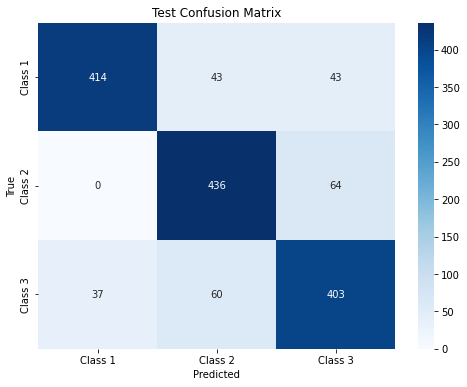

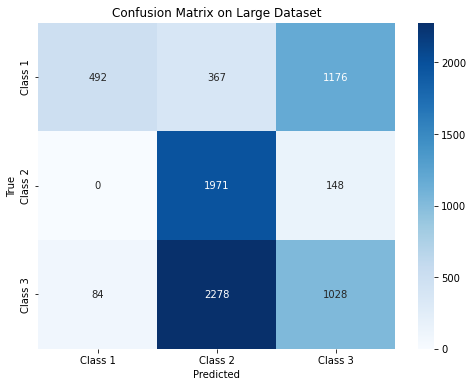

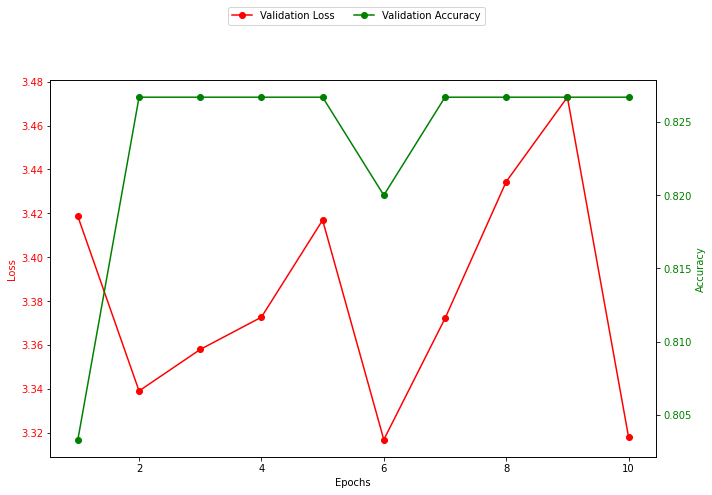

Smoothed plots have been displayed in the console and saved as images.


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.ndimage import gaussian_filter1d

# Confusion Matrix for Test Data
cm_test = np.array([[414, 43, 43],
                    [0, 436, 64],
                    [37, 60, 403]])

# Confusion Matrix for Large Dataset
cm_large = np.array([[492, 367, 1176],
                     [0, 1971, 148],
                     [84, 2278, 1028]])

# Plotting Confusion Matrix for Test Data
plt.figure(figsize=(8, 6))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 1', 'Class 2', 'Class 3'], yticklabels=['Class 1', 'Class 2', 'Class 3'])
plt.title('Test Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.savefig('./figures_mae_fewshot/prototypical/test_confusion_matrix.png')
plt.show()  # Display the plot
plt.close()

# Plotting Confusion Matrix for Large Dataset
plt.figure(figsize=(8, 6))
sns.heatmap(cm_large, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 1', 'Class 2', 'Class 3'], yticklabels=['Class 1', 'Class 2', 'Class 3'])
plt.title('Confusion Matrix on Large Dataset')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.savefig('./figures_mae_fewshot/prototypical/large_dataset_confusion_matrix.png')
plt.show()  # Display the plot
plt.close()

# Training and Validation Loss & Accuracy for 10 Epochs
epochs = list(range(1, 11))
val_loss = [3.4186, 3.3391, 3.3580, 3.3727, 3.4169, 3.3169, 3.3721, 3.4344, 3.4729, 3.3181]
val_accuracy = [0.8033, 0.8353, 0.8353, 0.8353, 0.8353, 0.8200, 0.8353, 0.8353, 0.8353, 0.8353]

smoothed_val_loss = val_loss
smoothed_val_accuracy = val_accuracy

# Plotting Validation Loss
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(epochs, smoothed_val_loss, marker='o', color='r', label='Validation Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss', color='r')
ax1.tick_params(axis='y', labelcolor='r')
ax1.set_title('Validation Loss')

# Saving the validation loss plot
plt.savefig('./figures_mae_fewshot/prototypical/val_loss.png')
plt.show()  # Display the plot
plt.close()

# Plotting Validation Accuracy
fig, ax2 = plt.subplots(figsize=(10, 6))
ax2.plot(epochs, smoothed_val_accuracy, marker='o', color='g', label='Validation Accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy', color='g')
ax2.tick_params(axis='y', labelcolor='g')
ax2.set_title('Validation Accuracy')

# Saving the validation accuracy plot
plt.savefig('./figures_mae_fewshot/prototypical/val_accuracy.png')
plt.show()  # Display the plot
plt.close()

print("Separate plots for Validation Loss and Accuracy have been displayed in the console and saved as images.")


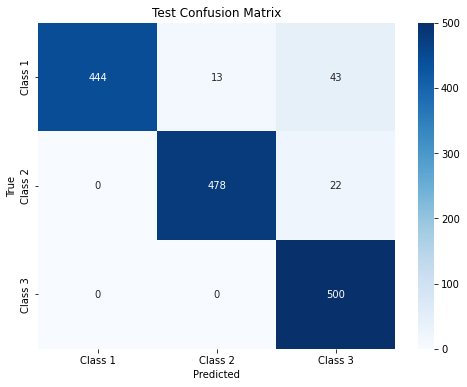

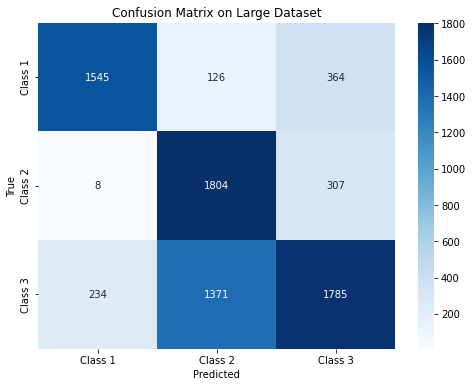

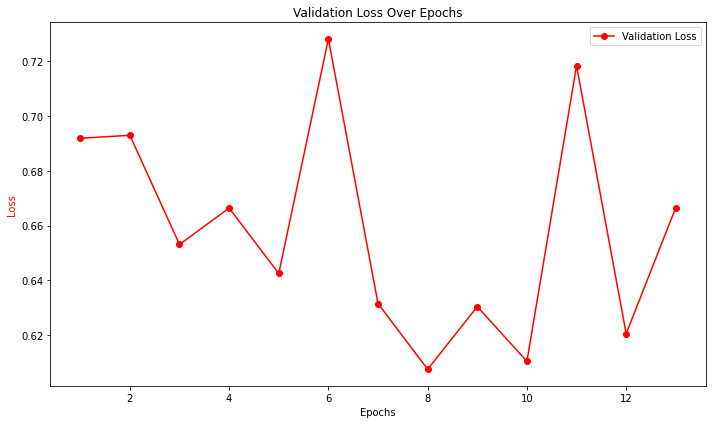

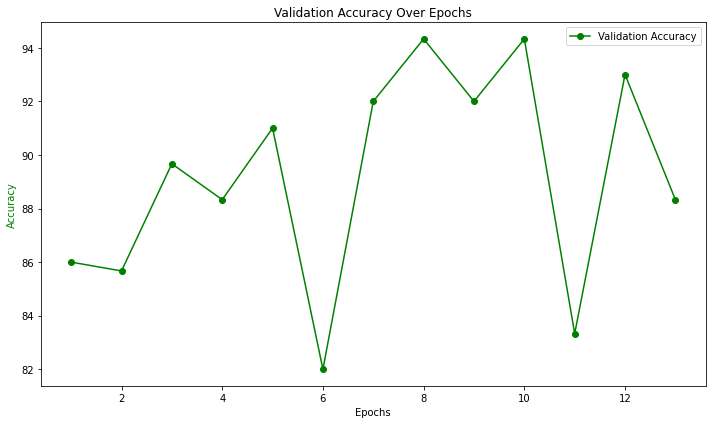

Smoothed plots for validation loss and accuracy have been displayed and saved as images.


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.ndimage import gaussian_filter1d

# Confusion Matrix for Test Data
cm_test = np.array([[444, 13, 43],
                    [0, 478, 22],
                    [0, 0, 500]])

# Confusion Matrix for Large Dataset
cm_large = np.array([[1545, 126, 364],
                     [8, 1804, 307],
                     [234, 1371, 1785]])

# Plotting Confusion Matrix for Test Data
plt.figure(figsize=(8, 6))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 1', 'Class 2', 'Class 3'], yticklabels=['Class 1', 'Class 2', 'Class 3'])
plt.title('Test Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.savefig('./figures_mae_fewshot/relation/test_confusion_matrix.png')
plt.show()  # Display the plot
plt.close()

# Plotting Confusion Matrix for Large Dataset
plt.figure(figsize=(8, 6))
sns.heatmap(cm_large, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 1', 'Class 2', 'Class 3'], yticklabels=['Class 1', 'Class 2', 'Class 3'])
plt.title('Confusion Matrix on Large Dataset')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.savefig('./figures_mae_fewshot/relation/large_dataset_confusion_matrix.png')
plt.show()  # Display the plot
plt.close()

# Training and Validation Loss & Accuracy for 50 Epochs
epochs = list(range(1, 14))  # Adjusting for the 13 epochs provided
train_loss = [
    0.7889, 0.7242, 0.6888, 0.6457, 0.6348, 0.6293, 0.6711, 0.6312, 0.6671,
    0.6117, 0.6493, 0.6775, 0.6366
]
val_loss = [
    0.6919, 0.6930, 0.6531, 0.6664, 0.6425, 0.7282, 0.6315, 0.6075, 0.6304,
    0.6104, 0.7184, 0.6205, 0.6666
]
val_accuracy = [
    86.00, 85.67, 89.67, 88.33, 91.00, 82.00, 92.00, 94.33, 92.00, 94.33,
    83.33, 93.00, 88.33
]

smoothed_val_loss = val_loss
smoothed_val_accuracy = val_accuracy

# Plotting Validation Loss
plt.figure(figsize=(10, 6))
plt.plot(epochs, smoothed_val_loss, marker='o', color='r', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss', color='r')
plt.title('Validation Loss Over Epochs')
plt.tight_layout()
plt.legend(loc='upper right')
plt.savefig('./figures_mae_fewshot/relation/val_loss.png')
plt.show()  # Display the plot
plt.close()

# Plotting Validation Accuracy
plt.figure(figsize=(10, 6))
plt.plot(epochs, smoothed_val_accuracy, marker='o', color='g', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy', color='g')
plt.title('Validation Accuracy Over Epochs')
plt.tight_layout()
plt.legend(loc='upper right')
plt.savefig('./figures_mae_fewshot/relation/val_accuracy.png')
plt.show()  # Display the plot
plt.close()

print("Smoothed plots for validation loss and accuracy have been displayed and saved as images.")


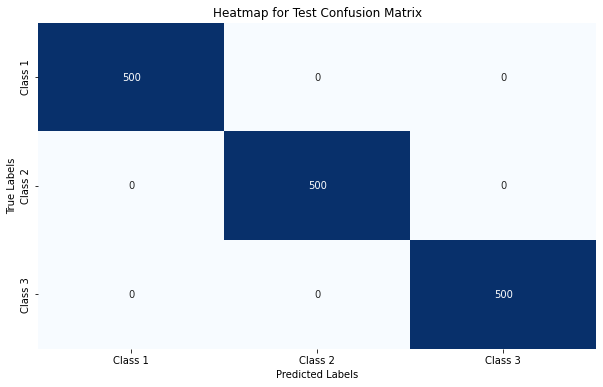

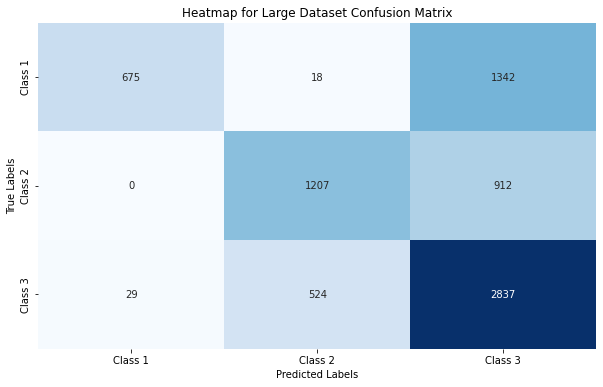

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Confusion Matrices
test_confusion_matrix = np.array([[500, 0, 0],
                                   [0, 500, 0],
                                   [0, 0, 500]])

large_dataset_confusion_matrix = np.array([[675, 18, 1342],
                                           [0, 1207, 912],
                                           [29, 524, 2837]])

# Plotting Test Confusion Matrix
plt.figure(figsize=(10, 6))
sns.heatmap(test_confusion_matrix, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['Class 1', 'Class 2', 'Class 3'], yticklabels=['Class 1', 'Class 2', 'Class 3'])
plt.title('Heatmap for Test Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Plotting Confusion Matrix on Large Dataset
plt.figure(figsize=(10, 6))
sns.heatmap(large_dataset_confusion_matrix, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['Class 1', 'Class 2', 'Class 3'], yticklabels=['Class 1', 'Class 2', 'Class 3'])
plt.title('Heatmap for Large Dataset Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()
